Testing draft pick and then value from draft value chart as baselines/comparisons to see how predictive they are of draft AV. Goal is to beat that.

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

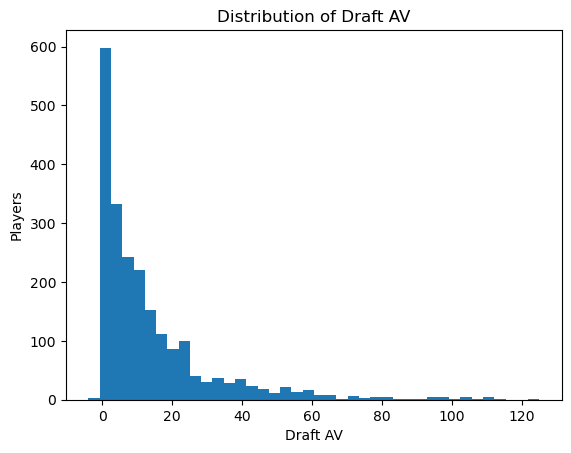

In [137]:
plt.hist(df['dr_av'], bins=40)
plt.xlabel("Draft AV")
plt.ylabel("Players")
plt.title("Distribution of Draft AV")
plt.show()

In [138]:
df = pd.read_csv("draft_values_vs_av_processed.csv")

df = df[['pick', 'dr_av']].dropna()
X = df[['pick']]
y = df['dr_av']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression using Draft Pick: RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")


# log(pick)
df['log_pick'] = np.log(df['pick'])
X = df[['log_pick']]
y = df['dr_av']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression using log of Draft Pick: RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")

Linear Regression using Draft Pick: RMSE=16.4634 MAE=11.1646 R2=0.1807
Linear Regression using log of Draft Pick: RMSE=16.1207 MAE=10.4203 R2=0.2144


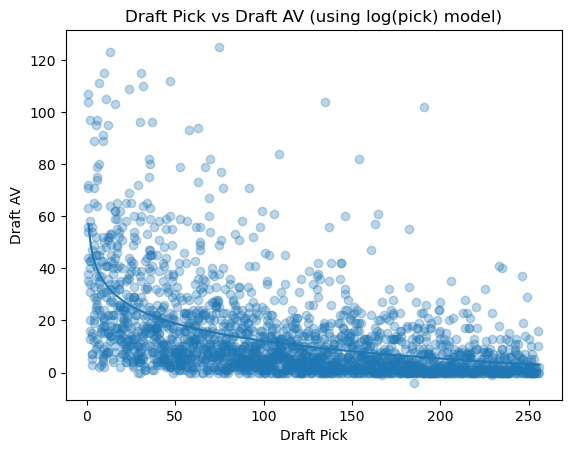

In [139]:
plt.scatter(df['pick'], df['dr_av'], alpha=0.3)

x_vals = np.linspace(df['pick'].min(), df['pick'].max(), 200)
x_log = pd.DataFrame({'log_pick': np.log(x_vals)})

y_vals = lr.predict(x_log)

plt.plot(x_vals, y_vals)

plt.xlabel("Draft Pick")
plt.ylabel("Draft AV")
plt.title("Draft Pick vs Draft AV (using log(pick) model)")
plt.show()

In [140]:
cols = ['stuart', 'johnson', 'hill', 'otc', 'pff', 'dr_av']
df = pd.read_csv("draft_values_vs_av_processed.csv")[cols].dropna()

# using each value chart individually
for col in ['stuart', 'johnson', 'hill', 'otc', 'pff']:
    
    X = df[[col]]
    y = df['dr_av']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Linear Regression using {col}: RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")

Linear Regression using stuart: RMSE=16.1217 MAE=10.4167 R2=0.2143
Linear Regression using johnson: RMSE=16.3432 MAE=10.4684 R2=0.1926
Linear Regression using hill: RMSE=16.1955 MAE=10.4369 R2=0.2071
Linear Regression using otc: RMSE=16.1208 MAE=10.4206 R2=0.2144
Linear Regression using pff: RMSE=16.2612 MAE=10.4869 R2=0.2007


In [141]:
# now trying polynomial regression using pick number as feature
df = pd.read_csv("draft_values_vs_av_processed.csv")[['pick', 'dr_av']].dropna()
X = df[['pick']]
y = df['dr_av']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

for d in [2,3,4]:
    model = Pipeline([("poly", PolynomialFeatures(degree=d)), ("lr", LinearRegression())])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Degree {d} polynomial RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")

Degree 2 polynomial RMSE=16.3206 MAE=10.7630 R2=0.1948
Degree 3 polynomial RMSE=16.2819 MAE=10.6034 R2=0.1986
Degree 4 polynomial RMSE=16.2640 MAE=10.5573 R2=0.2004


Draft value charts and pick number are very weak predictors of draft approximate value 